# Custom Problem Configuration

This notebook shows how to use the Job Shop Scheduling Environment to solve a custom defined JSP problem variant. It build upon a json based format for formulating a problem at hand, and uses the included parser to configure the JobShopEnv based on the provided data. One can then provide the envoronment to one of the included solution methods to solve the problem at hand. 

One can choose to formulate the following:

- Job shop or a Flow Shop problem
- Flexible Machine allocation (an operation can be processed on one or more machines)
- Assembly scheduling (an operation depends on multiple predecessors from different jobs to be complete to be started)
- Sequence dependent setup times (different setup times between different operations on the different machines)

Lets start with loading in the required imports:

In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
from data_parsers.custom_instance_parser import parse
from plotting.drawer import plot_gantt_chart, draw_precedence_relations

from solution_methods.GA.src.initialization import initialize_run
from solution_methods.GA.run_GA import run_GA
from solution_methods.cp_sat.run_cp_sat import run_CP_SAT

### Defining Custom Instance

We will solve a custom-defined problem instance, which we formulate in a JSON-based structure. For this, we define the nr of machines, the jobs (with their operations, processing times of operations on individual machines, and predecessor operation(s)), and the sequence-dependent setup times (configured between individual operations on the provided machines). 

Note: We recommend providing a new job_id to an operation that has multiple preceding operations.

In [14]:
processing_info = {
        "instance_name": "custom_problem_instance",
        "nr_machines": 2, 
        "jobs": [
            {"job_id": 0, "operations": [
                {"operation_id": 0, "processing_times": {"machine_1": 10, "machine_2": 20}, "predecessors": None},
                {"operation_id": 1, "processing_times": {"machine_1": 25, "machine_2": 19}, "predecessors": [0]}
            ]},
            {"job_id": 1, "operations": [
                {"operation_id": 2, "processing_times": {"machine_1": 23, "machine_2": 21}, "predecessors": None},
                {"operation_id": 3, "processing_times": {"machine_1": 12, "machine_2": 24}, "predecessors": [2]}
            ]},
            {"job_id": 2, "operations": [
                {"operation_id": 4, "processing_times": {"machine_1": 37, "machine_2": 21}, "predecessors": None},
                {"operation_id": 5, "processing_times": {"machine_1": 23, "machine_2": 34}, "predecessors": [4]}
            ]}
        ],
        "sequence_dependent_setup_times": {
            "machine_1": [
                [0, 25, 30, 35, 40, 45],
                [25, 0, 20, 30, 40, 50],
                [30, 20, 0, 10, 15, 25],
                [35, 30, 10, 0, 5, 10],
                [40, 40, 15, 5, 0, 20],
                [45, 50, 25, 10, 20, 0]
            ],
            "machine_2": [
                [0, 21, 30, 35, 40, 45],
                [21, 0, 10, 25, 30, 40],
                [30, 10, 0, 5, 15, 25],
                [35, 25, 5, 0, 10, 20],
                [40, 30, 15, 10, 0, 25],
                [45, 40, 25, 20, 25, 0]
            ]
        }
    }

In [15]:
def processing_info_func(path, instance_name):
    processing_info = {}
    processing_info['instance_name'] = instance_name
    
    with open(path, "r") as data:
        lines = data.readlines()
        
        total_jobs=int(lines[0].strip())
        total_machines=int(lines[1].strip())
        
        processing_info['nr_machines'] = total_machines
        
        # Parse the number of operations per job
        operation_counts = list(map(int, lines[2].strip().split()))
        assert len(operation_counts) == total_jobs, "Mismatch in job count and operation count."
        
        jobs_data = []
        
        # Processing times
        job_id = 0
        operation_id = 0
        current_line = 4
        
        # Map job IDs to their operation IDs
        job_to_operations = {}
        
        for num_operations in operation_counts:
            job_data = {"job_id" : job_id, "operations" : []}
            job_to_operations[job_id] = list(range(operation_id, operation_id + num_operations))
            
            for _ in range(num_operations):
                operation_data = {"operation_id" : operation_id, "processing_times": {}, "predecessors": []}
                num_options = list(map(int, lines[current_line].strip().split()))
                current_line += 1
                
                for option in range(num_options[0]):
                    options = list(map(int, lines[current_line].strip().split()))
                    machine_id, processing_time = options[0 + 2*option], options[1 + 2*option]
                    
                    operation_data["processing_times"][f"machine_{machine_id}"] = processing_time
                    
                current_line += 1
                
                # Handle precedence relations within the job
                if len(job_data["operations"]) > 0:
                    operation_data["predecessors"] = [job_data["operations"][-1]["operation_id"]]

                job_data["operations"].append(operation_data)
                operation_id += 1

            jobs_data.append(job_data)
            job_id += 1

            current_line += 1
        
        processing_info["jobs"] = jobs_data
        
        # SDST
        setup_matrix = []
        
        current_line += 1 # Skip empty line
        
        for line in range(current_line, current_line + total_jobs + 1):
            setup_matrix.append(list(map(int, lines[line].strip().split())))
            
        # initialize the output structure
        setup_times = {f"machine_{i+1}": [[0] * (sum(operation_counts)+1) for _ in range(sum(operation_counts) + 1)]
                       for i in range(total_machines)}
        
        # parse the initial setup times
        initial_setup_times = setup_matrix[0]
        
        # fill the initial setup times for each machine
        for job_position in range(total_jobs):
            for machine_id in range(total_machines):
                setup_time = initial_setup_times[job_position * total_machines + machine_id]
                
                # Assign the setup time to all operations of the job
                for operation_id in job_to_operations[job_position]:
                    setup_times[f"machine_{machine_id + 1}"][0][operation_id + 1] = setup_time
                   
        # Parse the transition setup times (remaining rows)
        for job_id in range(1, total_jobs + 1):
            transition_setup_times = setup_matrix[job_id]
            
            for j in range(len(transition_setup_times)):
                # Calculate the predecessor job and machine
                predecessor_job = j // total_machines
                machine_id = j % total_machines
                
                # Assign the setup time to the correct position in the setup matrix
                setup_time = transition_setup_times[j]
                
                # Assign the setup time to all pairs of operations between the predecessor job and the current job
                for op1 in job_to_operations[predecessor_job]:
                    for op2 in job_to_operations[job_id-1]:
                        setup_times[f"machine_{machine_id + 1}"][op1 + 1][op2 + 1] = setup_time
    
    processing_info["sequence_dependent_setup_times"] = setup_times
    
    return processing_info

In [16]:
# processing_info = processing_info_func('Shen instances/test_a/petter_test', 'petter_test')

processing_info = processing_info_func('Shen instances/test_a/test01a', 'test01a')

# Disregard box below. Tried to look into KeyError.

In [23]:
# KeyError: Machine 4, Operation 73, idx 34
from solution_methods.helper_functions import load_job_shop_env

parser = argparse.ArgumentParser(description="Run OR-Tools CP-SAT")
parser.add_argument(
    "-f", "--config_file",
    type=str,
    default=PARAM_FILE,
    help="Path to the configuration file.",
    )
args = parser.parse_args()


parameters = load_parameters(param_file)
jobShopEnv = load_job_shop_env(parameters['instance'].get('problem_instance'))
operation_identifier = {(job_id, op_id): job_id * len(jobShopEnv.jobs[0].operations) + op_id for job_id, job in enumerate(jobShopEnv.jobs) for op_id, op in enumerate(job.operations)}
machine_schedule = {machine: {} for machine in jobShopEnv.machines}




# processing_info["processing_times"]
# processing_info[machine]

{'instance_name': 'test01a',
 'nr_machines': 5,
 'jobs': [{'job_id': 0,
   'operations': [{'operation_id': 0,
     'processing_times': {'machine_1': 42},
     'predecessors': []},
    {'operation_id': 1,
     'processing_times': {'machine_3': 62},
     'predecessors': [0]},
    {'operation_id': 2,
     'processing_times': {'machine_5': 22},
     'predecessors': [1]},
    {'operation_id': 3,
     'processing_times': {'machine_4': 16},
     'predecessors': [2]},
    {'operation_id': 4,
     'processing_times': {'machine_1': 96, 'machine_3': 96, 'machine_5': 96},
     'predecessors': [3]},
    {'operation_id': 5,
     'processing_times': {'machine_5': 24},
     'predecessors': [4]},
    {'operation_id': 6,
     'processing_times': {'machine_1': 63},
     'predecessors': [5]},
    {'operation_id': 7,
     'processing_times': {'machine_2': 29},
     'predecessors': [6]},
    {'operation_id': 8,
     'processing_times': {'machine_3': 83},
     'predecessors': [7]},
    {'operation_id': 9,
  

### Intrepretting configured Instances

By plotting the different jobs, operations and their precedence constratints, we can inspect wether the configred job:

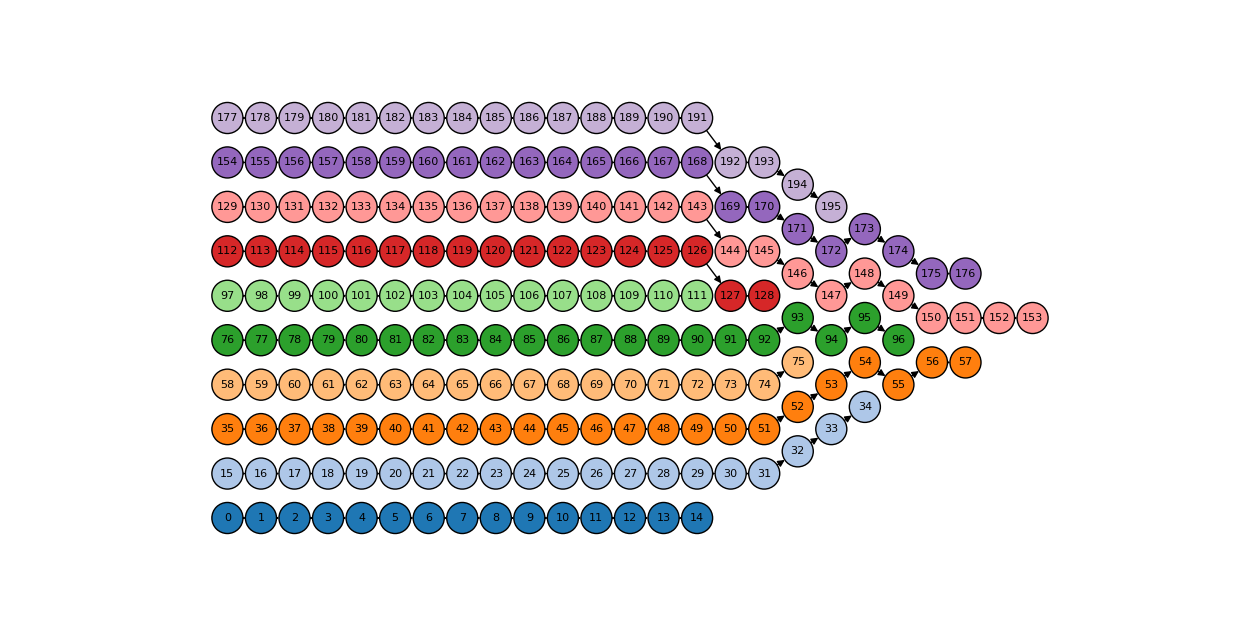

In [18]:
jobShopEnv = parse(processing_info)
draw_precedence_relations(jobShopEnv)

### CP-SAT solver

In the code below we configure the OR-TOOLS CP-SAT solver to solve the defined problem. For this, we decide one the time limit for the solver (in seconds) and what model to use (current implementations allows for: jsp, fsp, fjsp and fjsp_sdst).

In [19]:
from data_parsers.custom_instance_parser import parse
from plotting.drawer import plot_gantt_chart, draw_precedence_relations

from solution_methods.GA.src.initialization import initialize_run
from solution_methods.GA.run_GA import run_GA
from solution_methods.cp_sat.run_cp_sat import run_CP_SAT

KeyError: Machine 0, Operations 48 and 48
KeyError: Machine 0, Operations 124 and 124
KeyError: Machine 0, Operations 137 and 137
KeyError: Machine 0, Operations 142 and 142
KeyError: Machine 2, Operations 128 and 128
KeyError: Machine 2, Operations 139 and 139
KeyError: Machine 4, Operations 33 and 33
KeyError: Machine 4, Operations 79 and 79
KeyError: Machine 3, Operations 75 and 75
KeyError: Machine 3, Operations 120 and 120
KeyError: Machine 3, Operations 129 and 129
KeyError: Machine 1, Operations 60 and 60
KeyError: Machine 1, Operations 77 and 77
KeyError: Machine 1, Operations 106 and 106
Solution 0, time = 4.503210 s, objective = 10463
Solution 1, time = 5.494595 s, objective = 10009
Solution 2, time = 6.276495 s, objective = 9822
Solution 3, time = 6.541601 s, objective = 4930
Solution 4, time = 6.817564 s, objective = 4929
Solution 5, time = 6.885964 s, objective = 4928
Solution 6, time = 6.928958 s, objective = 4927
Solution 7, time = 7.960958 s, objective = 4920
Solution 8

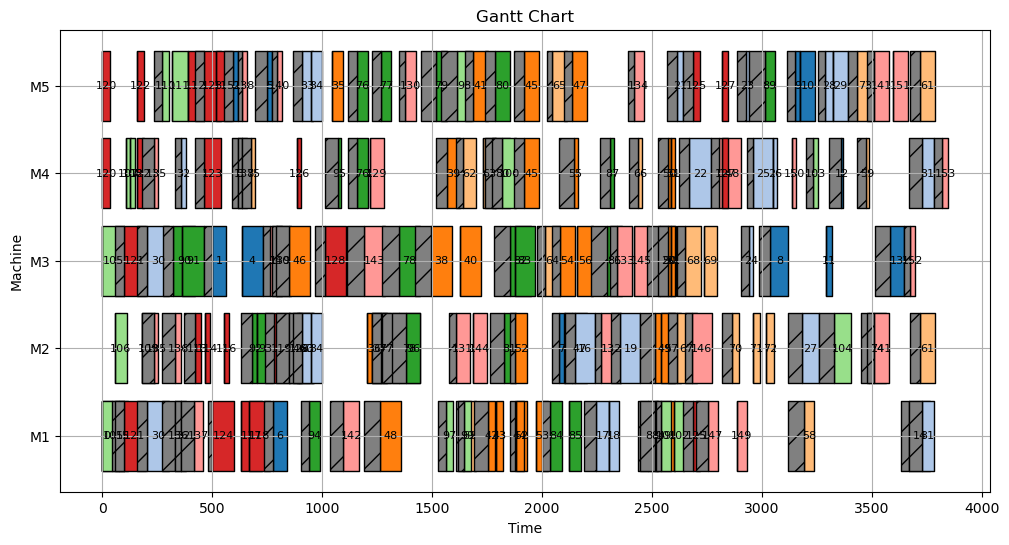

In [20]:
parameters = {"instance": {"problem_instance": "custom_problem_instance"},
             "solver": {"time_limit": 60, "model": "fjsp_sdst"},
             "output": {"logbook": True}
             }

jobShopEnv = parse(processing_info)
results, jobShopEnv = run_CP_SAT(jobShopEnv, **parameters)

plt = plot_gantt_chart(jobShopEnv)
plt.show()

### Genetic Algorithm

In the code below we configure the Genetic Algorithm (GA) to solve the defined problem. For this, we decide on the population size, number of search generations (ngen), crossover rate (cr), and mutation probability (input). We also specify 'multiprocessing' as true to allow for parallel evaluation of the different obtained solutions in the different generations of the search.

INFO:root:gen	avg     	std           	min    	max    
0  	[6192.6]	[330.04127015]	[5436.]	[6502.]
INFO:root:
INFO:root:1  	[5671.6]	[327.27364697]	[5146.]	[6379.]
INFO:root:2  	[5446.3]	[193.6652008] 	[5191.]	[5742.]
INFO:root:3  	[5309.3]	[116.87433422]	[5191.]	[5555.]
INFO:root:4  	[5267.2]	[43.26846427] 	[5212.]	[5343.]
INFO:root:5  	[5249.4]	[81.61887037] 	[5119.]	[5394.]
INFO:root:6  	[5215.8]	[63.71938481] 	[5119.]	[5287.]
INFO:root:7  	[5211.6]	[57.72902216] 	[5163.]	[5339.]
INFO:root:8  	[5231.2]	[100.60397606]	[5163.]	[5483.]
INFO:root:9  	[5199.8]	[64.57213021] 	[5154.]	[5350.]
INFO:root:10 	[5226.6]	[124.51441684]	[5154.]	[5562.]
INFO:root:11 	[5182.3]	[32.60383413] 	[5154.]	[5272.]
INFO:root:12 	[5154.4]	[34.48825887] 	[5091.]	[5197.]
INFO:root:13 	[5176.8]	[38.39218671] 	[5091.]	[5254.]
INFO:root:14 	[5184.1]	[46.92003836] 	[5163.]	[5323.]
INFO:root:15 	[5188.9]	[77.06030106] 	[5142.]	[5418.]
INFO:root:16 	[5190.3]	[80.56308087] 	[5142.]	[5428.]
INFO:root:17 	[5156.2]	[122

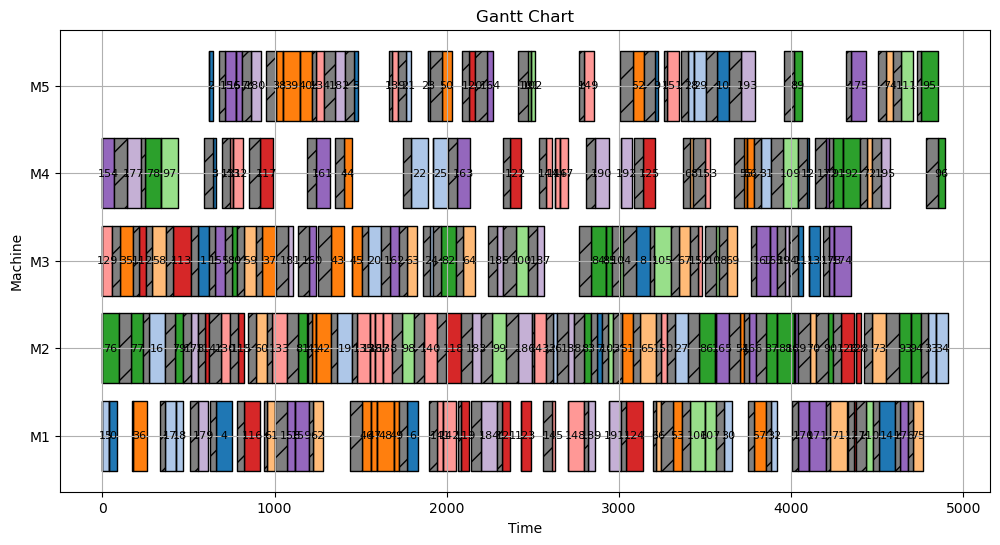

In [21]:
parameters = {"instance": {"problem_instance": "custom_problem_instance"},
             "algorithm": {"population_size": 10, "ngen": 10, "seed": 5, "cr": 0.7, "indpb": 0.2, 'multiprocessing': True},
             "output": {"logbook": True}
             }

jobShopEnv = parse(processing_info)
population, toolbox, stats, hof = initialize_run(jobShopEnv, **parameters)
makespan, jobShopEnv = run_GA(jobShopEnv, population, toolbox, stats, hof, **parameters)

plt = plot_gantt_chart(jobShopEnv)
plt.show()